Ciclo INTERVENSIONISMO ESTATAL ignorado (fuera de rango)


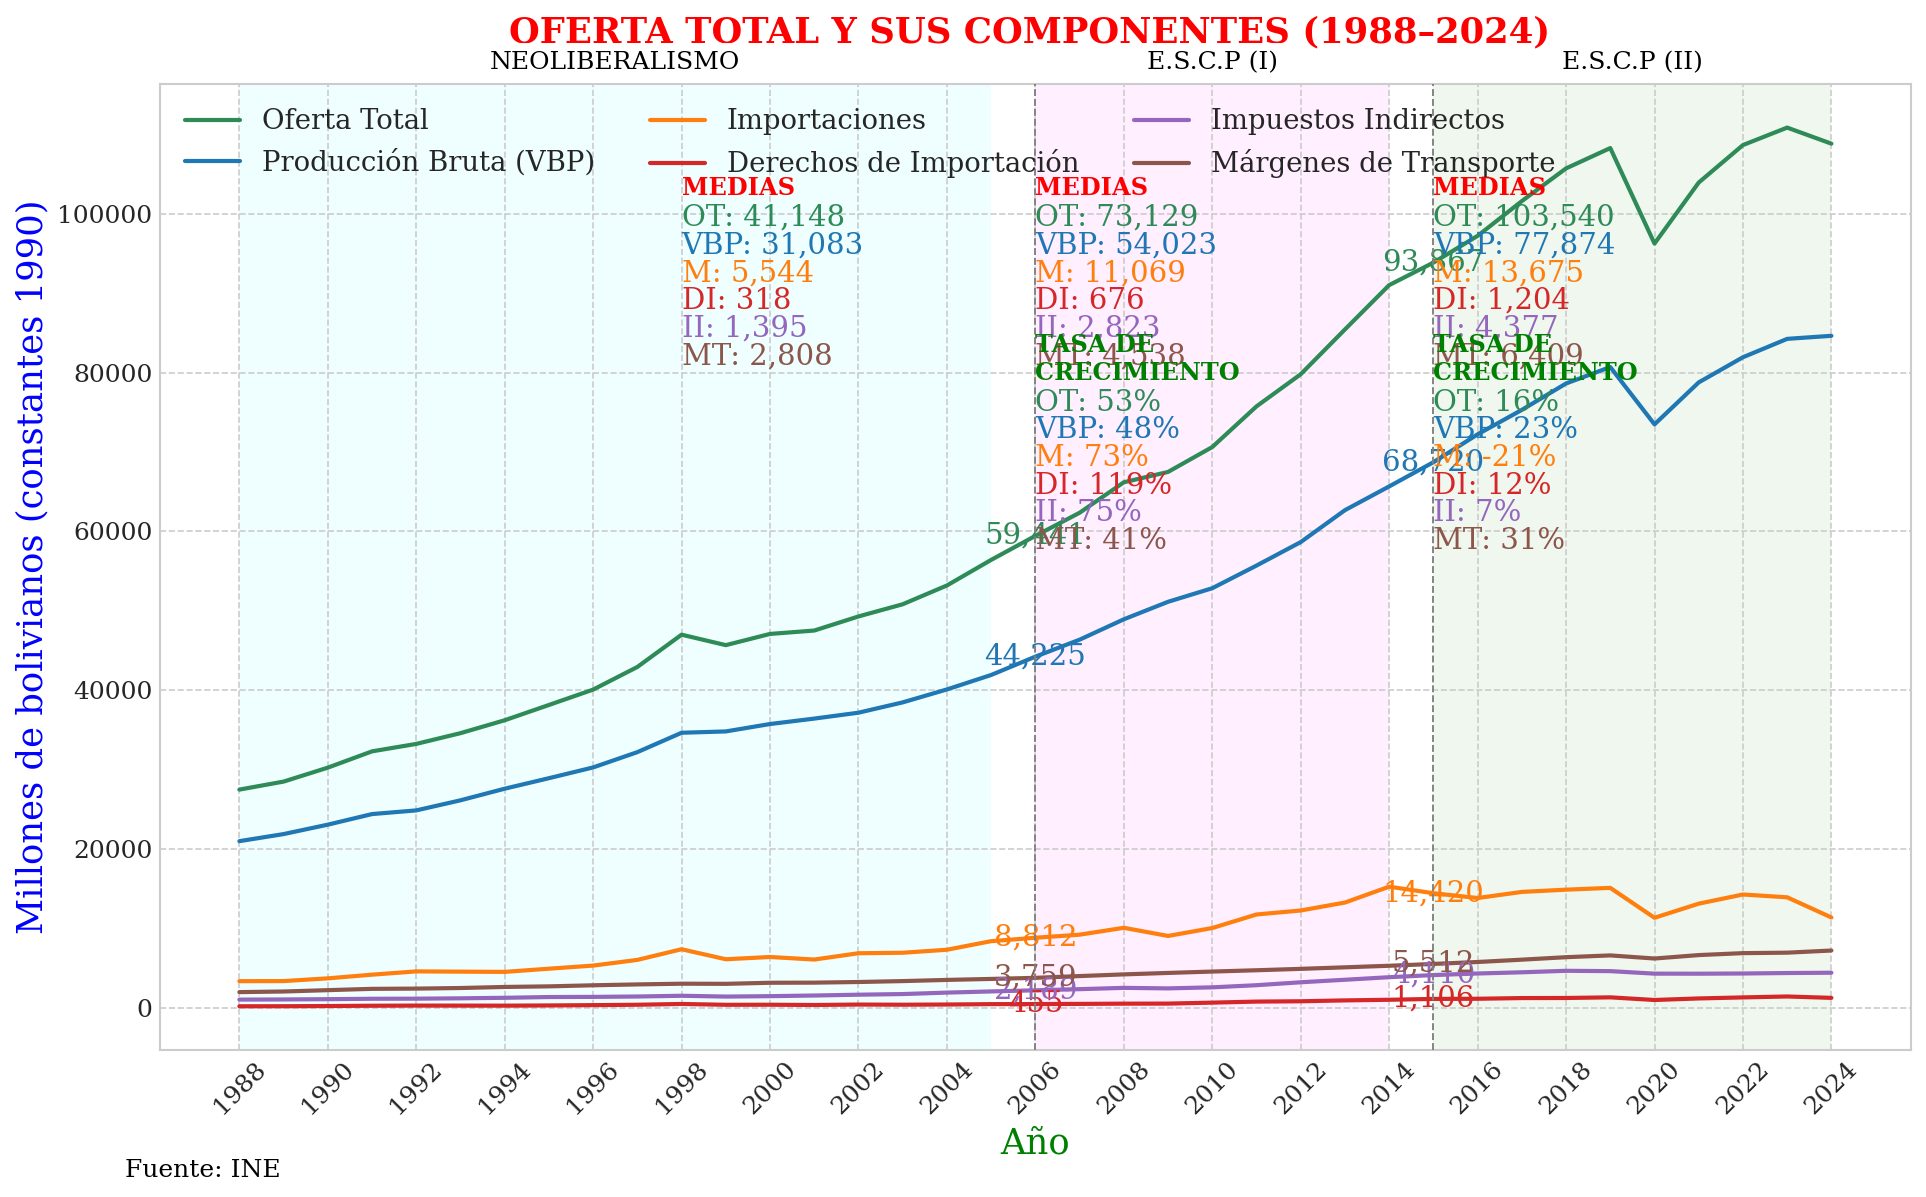

In [1]:
# ═══════════════════════════════════════════════════════════════════
# GRÁFICA DE PERÍODOS ESTRUCTURALES — OFERTA_TOTAL
# ═══════════════════════════════════════════════════════════════════
import os
import sys
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from func_auxiliares.graficos_utils import (
    set_style,
    init_base_plot,
    add_hitos,
    add_cycle_means_multi,
    add_year_value_annotations,
    add_period_growth_annotations_multi,
    add_participation_cycle_boxes,
    adjust_annot_years,
    adjust_cycles,
    adjust_periods,
    add_period_backgrounds,
)

from func_auxiliares.config import (
    DB_PATH,
    ASSETS_DIR,
    CYCLES_PERIODOS,
    annot_years_periodos,
    periodos_tasas_periodos,
    hitos_v_periodos,
)

# ─────────────────────── 1. CONFIGURACIÓN GENERAL ───────────────────
output_dir = ASSETS_DIR / "serie_completa" / "oferta_total"
os.makedirs(output_dir, exist_ok=True)
set_style()

# ─────────────────────────── 2. CARGA DE DATOS ──────────────────────
with sqlite3.connect(str(DB_PATH)) as conn:
    df = (
        pd.read_sql(
            "SELECT * FROM oferta_total",
            conn,
            index_col="año",
        )
        .sort_index()
    )
    valor_cols = ['oferta_total', 'produccion_bruta', 'importaciones', 'derechos_imp', 'impuestos_ind', 'margenes_transp']
    df[valor_cols] = df[valor_cols] / 1000

# ──────────────── 3. COMPONENTES, COLORES Y ABREVIATURAS ────────────
componentes = [
    ('oferta_total', 'Oferta Total'),
    ('produccion_bruta', 'Producción Bruta (VBP)'),
    ('importaciones', 'Importaciones'),
    ('derechos_imp', 'Derechos de Importación'),
    ('impuestos_ind', 'Impuestos Indirectos'),
    ('margenes_transp', 'Márgenes de Transporte'),
]
cols_componentes = [col for col, _ in componentes]

colors = {
    'oferta_total': '#2E8B57',
    'produccion_bruta': '#1f77b4',
    'importaciones': '#ff7f0e',
    'derechos_imp': '#d62728',
    'impuestos_ind': '#9467bd',
    'margenes_transp': '#8c564b',
}

abbr_map = {
    'oferta_total': 'OT',
    'produccion_bruta': 'VBP',
    'importaciones': 'M',
    'derechos_imp': 'DI',
    'impuestos_ind': 'II',
    'margenes_transp': 'MT',
}

# ──────────────── 4. PREPARACIÓN DE CICLOS Y PERÍODOS ───────────────
annotate_years = adjust_annot_years(df, annot_years_periodos)
cycles         = adjust_cycles(df, CYCLES_PERIODOS)
periods        = adjust_periods(df, periodos_tasas_periodos)

cycle_stats = {
    name: df.loc[period, cols_componentes].mean().to_dict()
    for name, period in cycles.items()
}

# ───────────────────── 5. OFFSETS DE POSICIONAMIENTO ────────────────
hitos_offset_periodos = {year: 0.8 for year in hitos_v_periodos}

# Anotaciones de valores en años clave
annotation_offsets = {
    'oferta_total': {
        1952: (0, 0), 1985: (0, 0), 2006: (0, 0), 2014: (0, 0), 2015: (0, 0), 2022: (0, 0),
    },
    'produccion_bruta': {
        1952: (0, 0), 1985: (0, 0), 2006: (0, 0), 2014: (0, 0), 2015: (0, 0), 2022: (0, 0),
    },
    'importaciones': {
        1952: (0, 0), 1985: (0, 0), 2006: (0, 0), 2014: (0, 0), 2015: (0, 0), 2022: (0, 0),
    },
    'derechos_imp': {
        1952: (0, 0), 1985: (0, 0), 2006: (0, 0), 2014: (0, 0), 2015: (0, 0), 2022: (0, 0),
    },
    'impuestos_ind': {
        1952: (0, 0), 1985: (0, 0), 2006: (0, 0), 2014: (0, 0), 2015: (0, 0), 2022: (0, 0),
    },
    'margenes_transp': {
        1952: (0, 0), 1985: (0, 0), 2006: (0, 0), 2014: (0, 0), 2015: (0, 0), 2022: (0, 0),
    },
}

# Posición de medias por período
medias_offsets = {
    "INTERVENSIONISMO ESTATAL": (1960, 0.90),
    "NEOLIBERALISMO": (1998, 0.90),
    "E.S.C.P (I)":    (2006, 0.90),
    "E.S.C.P (II)":   (2015, 0.90),
}

# Posición de tasas de crecimiento
tasas_offsets = {
    "1952-1984": (1960, 0.73),
    "1985-2005": (1998, 0.73),
    "2006-2014": (2006, 0.73),
    "2015-2024": (2015, 0.73),
}

participacion_offsets = {
    "1952-1984": (1960, 0.56),
    "1985-2005": (1998, 0.56),
    "2006-2014": (2006, 0.56),
    "2015-2024": (2015, 0.56),
}

# ────────────────────────── 6. GRÁFICO BASE ─────────────────────────
fig, ax = init_base_plot(
    df=df,
    series=componentes,
    colors=colors,
    title=f"OFERTA TOTAL Y SUS COMPONENTES ({df.index.min()}–{df.index.max()}) ",
    xlabel="Año",
    ylabel="Millones de bolivianos (constantes 1990)",
    source_text="Fuente: INE",
)

# ──────────────────── 7. ELEMENTOS GRÁFICOS ─────────────────────────
add_hitos(
    ax, 
    df.index, 
    hitos_v_periodos, 
    hitos_offset_periodos, 
    line_kwargs={"lw": 0.9}
)

add_cycle_means_multi(
    ax, cycle_stats, medias_offsets,
    abbr_map, colors,
    line_spacing=ax.get_ylim()[1] * 0.03,
)

add_year_value_annotations(
    ax, df, annotate_years,
    cols_componentes, annotation_offsets, colors,
    arrow_lw=0.5,
)

add_period_growth_annotations_multi(
    ax, df, periods,
    cols_componentes, tasas_offsets,
    colors, abbr_map,
)

add_period_backgrounds(
    ax,
    periods,
)

# ────────────────────────── 8. GUARDADO ─────────────────────────────
plt.tight_layout()
fig.savefig(output_dir / "oferta_total_periodos.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()
